In [1]:
import pandas as pd
import os
from pathlib import Path

experiment_logs_path = Path(r"logs\Experiment2and3")

results_df = pd.read_csv(experiment_logs_path / "metrics_per_image.csv")

results_df

,Architecture,Encoder,Pretrained,Participant,File,Dice,IoU
0,unet,efficientnet-b0,scratch,65,0.png,0.948809,0.902604
1,unet,efficientnet-b0,scratch,65,1.png,0.940067,0.886912
2,unet,efficientnet-b0,scratch,65,10.png,0.926083,0.862342
3,unet,efficientnet-b0,scratch,65,11.png,0.960857,0.924662
4,unet,efficientnet-b0,scratch,65,12.png,0.963631,0.929815
...,...,...,...,...,...,...,...
362951,unet++,resnet34,same-dataset,99,5.png,0.988200,0.976675
362952,unet++,resnet34,same-dataset,99,6.png,0.958093,0.919557
362953,unet++,resnet34,same-dataset,99,7.png,0.925802,0.861855
362954,unet++,resnet34,same-dataset,99,8.png,0.963869,0.930258


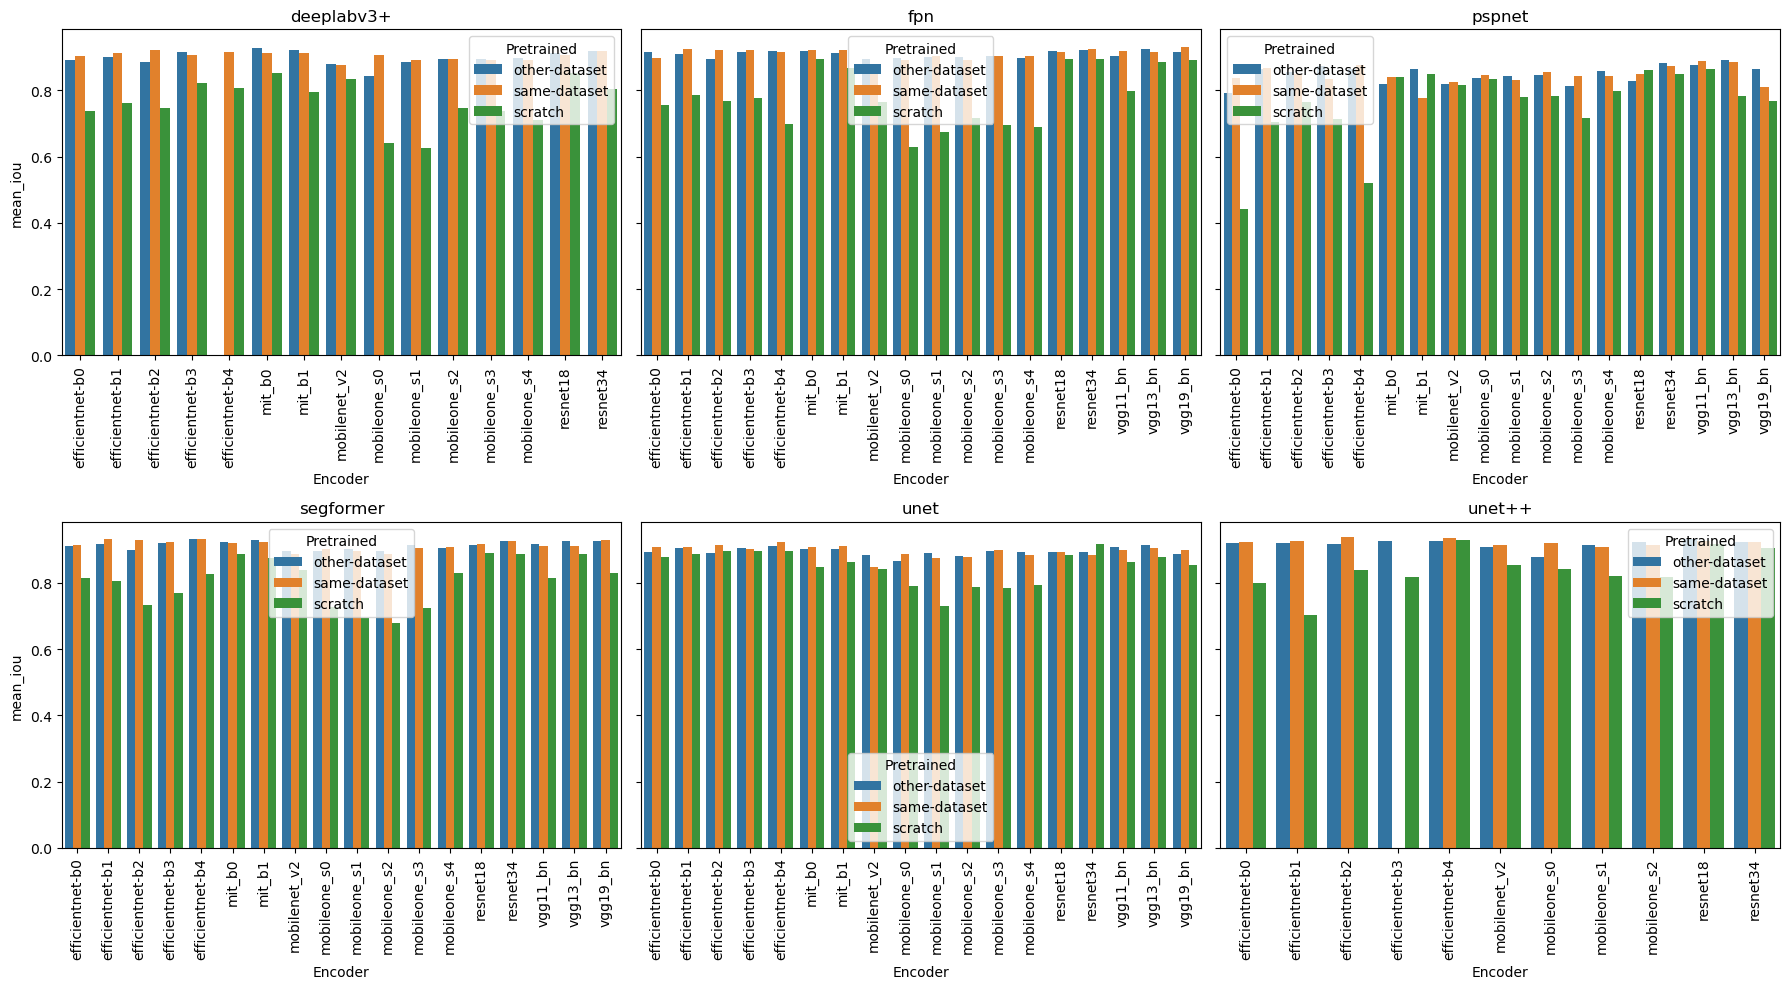

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plot_df = (
    results_df
    .groupby(["Architecture", "Encoder", "Pretrained"])
    .agg(
        mean_iou=("IoU", "mean"),
        std_iou=("IoU", "std"),
        n=("IoU", "count")
    )
    .reset_index()
)

plot_df["ci95"] = 1.96 * plot_df["std_iou"] / np.sqrt(plot_df["n"])

architectures = plot_df["Architecture"].unique()

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10),
    sharey=True
)

axes = axes.flatten()

for ax, arch in zip(axes, architectures):

    tmp = plot_df[plot_df["Architecture"] == arch]

    sns.barplot(
        data=tmp,
        x="Encoder",
        y="mean_iou",
        hue="Pretrained",
        ax=ax,
        errorbar=None
    )

    ax.set_title(arch)
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

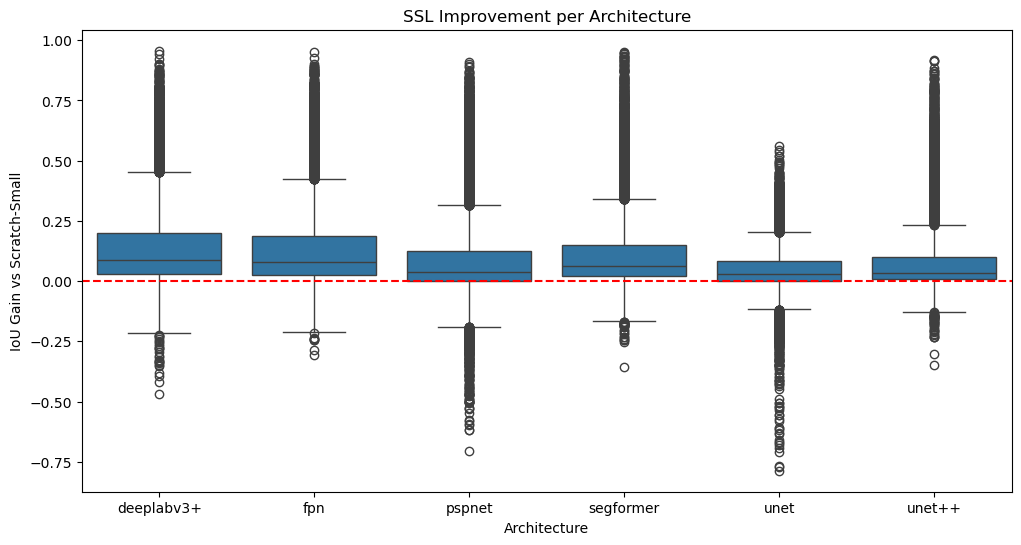

In [7]:
results_iou = results_df.pivot_table(
    index=["Architecture", "Encoder", "Participant", "File"],
    columns="Pretrained",
    values="IoU"
)

results_iou["gain_same"] = (
    results_iou["same-dataset"]
    - results_iou["scratch"]
)

results_iou["gain_other"] = (
    results_iou["other-dataset"]
    - results_iou["scratch"]
)

gains = results_iou.reset_index()

fig, ax = plt.subplots(figsize=(12,6))

sns.boxplot(
    data=gains,
    x="Architecture",
    y="gain_same",
    ax=ax
)

ax.axhline(
    0,
    color="red",
    linestyle="--"
)

ax.set_ylabel("IoU Gain vs Scratch-Small")
ax.set_title("SSL Improvement per Architecture")

plt.show()

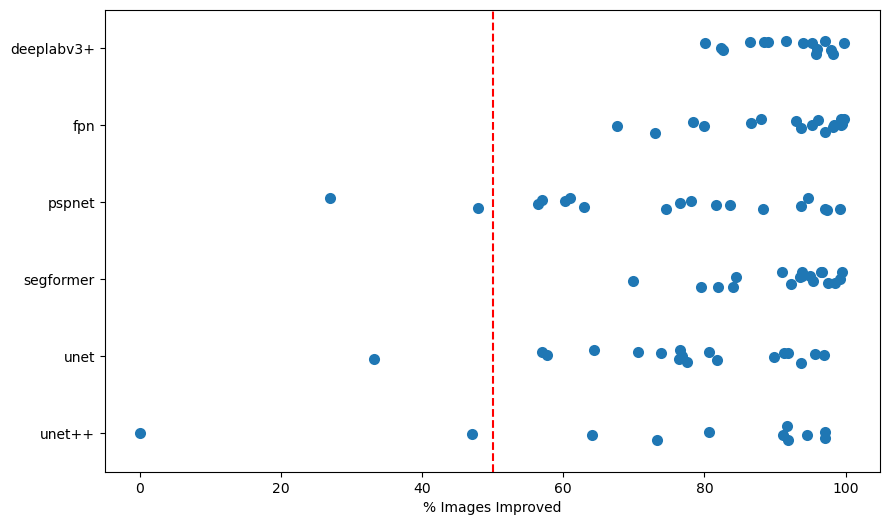

In [13]:
summary = []

for (arch, encoder), group in gains.groupby(
    ["Architecture", "Encoder"]
):

    pct_improved = (
        group["gain_same"] > 0
    ).mean() * 100

    summary.append(
        {
            "Architecture": arch,
            "Encoder": encoder,
            "ImprovedPercent": pct_improved
        }
    )

improved_df = pd.DataFrame(summary)

plt.figure(figsize=(10,6))

sns.stripplot(
    data=improved_df,
    x="ImprovedPercent",
    y="Architecture",
    size=8
)

plt.axvline(50, color="red", linestyle="--")

plt.xlabel("% Images Improved")
plt.ylabel("")
plt.show()



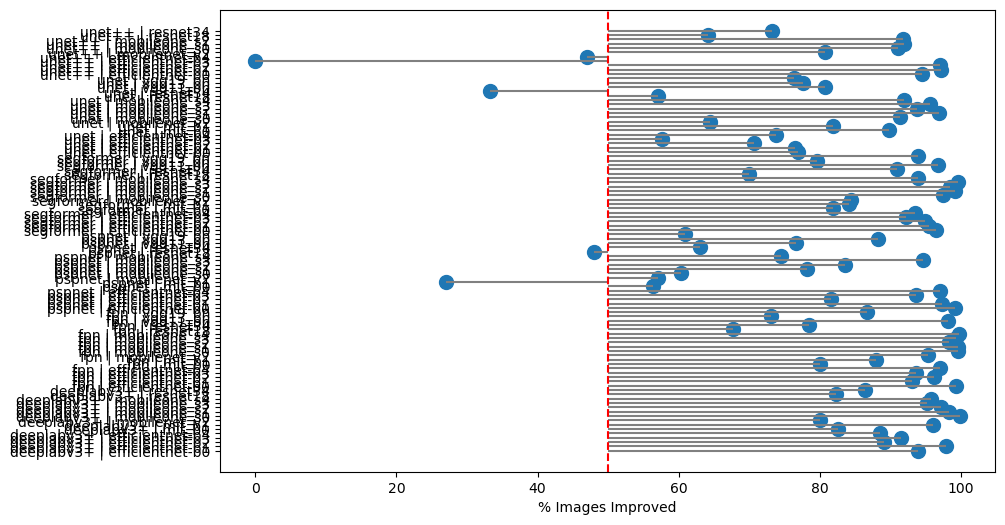

In [14]:
tmp = improved_df.sort_values("ImprovedPercent")

plt.figure(figsize=(10,6))

plt.hlines(
    y=tmp.index,
    xmin=50,
    xmax=tmp["ImprovedPercent"],
    color="gray"
)

plt.scatter(
    tmp["ImprovedPercent"],
    tmp.index,
    s=100
)

plt.axvline(50, ls="--", c="red")

plt.yticks(tmp.index, tmp["Architecture"] + " | " + tmp["Encoder"])

plt.xlabel("% Images Improved")
plt.show()

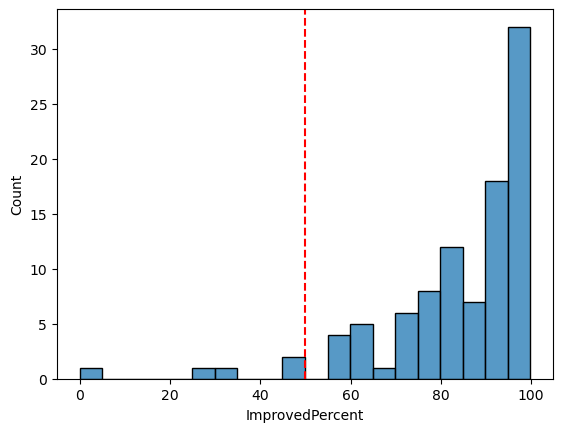

In [15]:
sns.histplot(
    improved_df["ImprovedPercent"],
    bins=20
)

plt.axvline(
    50,
    color="red",
    linestyle="--"
)

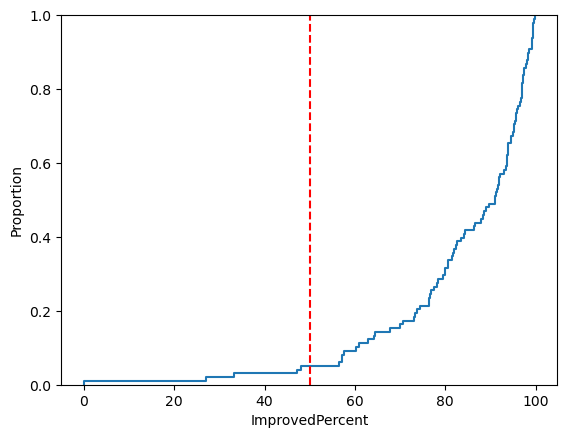

In [16]:
sns.ecdfplot(
    improved_df["ImprovedPercent"]
)

plt.axvline(
    50,
    color="red",
    linestyle="--"
)

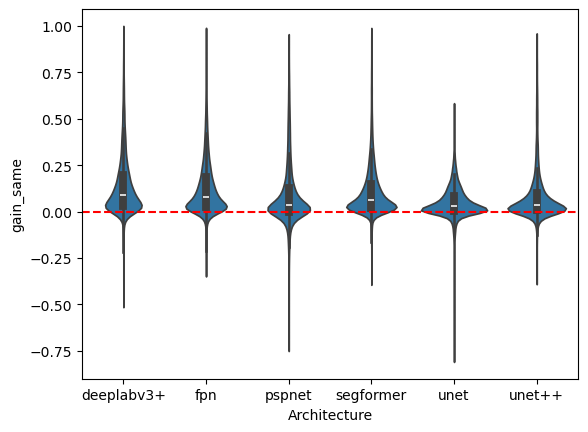

In [18]:
sns.violinplot(
    data=gains.reset_index(),
    x="Architecture",
    y="gain_same"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)
plt.show()

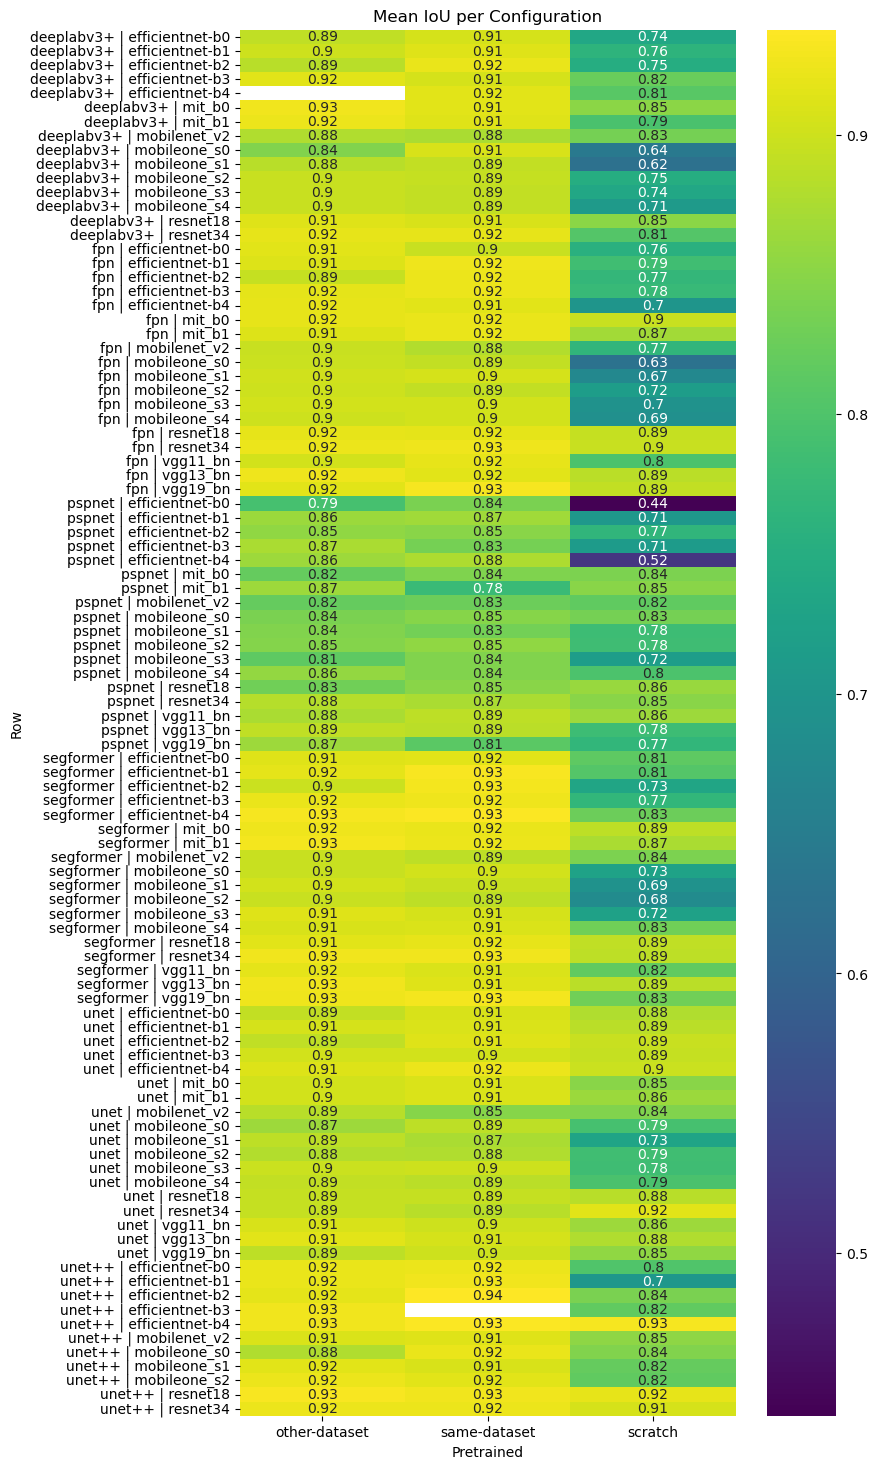

In [9]:
heatmap_df = (
    results_df
    .groupby(
        ["Architecture", "Encoder", "Pretrained"]
    )["IoU"]
    .mean()
    .reset_index()
)

heatmap_df["Row"] = (
    heatmap_df["Architecture"]
    + " | "
    + heatmap_df["Encoder"]
)

heatmap_data = heatmap_df.pivot(
    index="Row",
    columns="Pretrained",
    values="IoU"
)

plt.figure(figsize=(8,18))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="viridis"
)

plt.title("Mean IoU per Configuration")

plt.show()

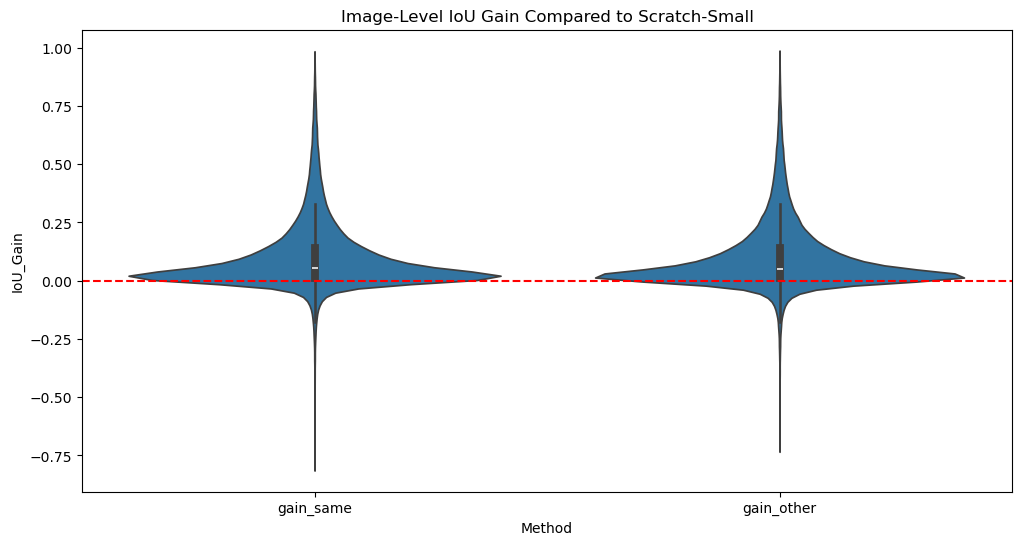

In [10]:
plot_df = gains.melt(
    id_vars=["Architecture", "Encoder"],
    value_vars=["gain_same", "gain_other"],
    var_name="Method",
    value_name="IoU_Gain"
)

plt.figure(figsize=(12,6))

sns.violinplot(
    data=plot_df,
    x="Method",
    y="IoU_Gain"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title(
    "Image-Level IoU Gain Compared to Scratch-Small"
)

plt.show()

In [2]:
# pivot value: Dice, column: Pretrained, index: Architecture, Encoder

results_dice = results_df.pivot_table(index=['Architecture', 'Encoder', 'Participant', 'File'], columns='Pretrained', values='Dice', aggfunc='max')

display(results_dice)

results_iou = results_df.pivot_table(index=['Architecture', 'Encoder', 'Participant', 'File'], columns='Pretrained', values='IoU', aggfunc='mean')

display(results_iou)

Pretrained                                       other-dataset  same-dataset  \
Architecture Encoder         Participant File                                  
deeplabv3+   efficientnet-b0 7           0.png        0.951921      0.956397   
                                         1.png        0.963416      0.975814   
                                         10.png       0.971057      0.972138   
                                         11.png       0.971710      0.956447   
                                         12.png       0.974952      0.975397   
...                                                        ...           ...   
unet++       resnet34        99          5.png        0.978353      0.988200   
                                         6.png        0.953186      0.958093   
                                         7.png        0.895317      0.925802   
                                         8.png        0.932832      0.963869   
                                         9.png        0.921235      0.954422   

Pretrained                                        scratch  
Architecture Encoder         Participant File              
deeplabv3+   efficientnet-b0 7           0.png   0.938271  
                                         1.png   0.905086  
                                         10.png  0.752115  
                                         11.png  0.779255  
                                         12.png  0.815711  
...                                                   ...  
unet++       resnet34        99          5.png   0.973042  
                                         6.png   0.961388  
                                         7.png   0.919477  
                                         8.png   0.958178  
                                         9.png   0.969680  

[121814 rows x 3 columns]

Pretrained                                       other-dataset  same-dataset  \
Architecture Encoder         Participant File                                  
deeplabv3+   efficientnet-b0 7           0.png        0.908253      0.916438   
                                         1.png        0.929415      0.952771   
                                         10.png       0.943743      0.945786   
                                         11.png       0.944976      0.916530   
                                         12.png       0.951129      0.951975   
...                                                        ...           ...   
unet++       resnet34        99          5.png        0.957624      0.976675   
                                         6.png        0.910559      0.919557   
                                         7.png        0.810475      0.861855   
                                         8.png        0.874120      0.930258   
                                         9.png        0.853971      0.912817   

Pretrained                                        scratch  
Architecture Encoder         Participant File              
deeplabv3+   efficientnet-b0 7           0.png   0.883720  
                                         1.png   0.826627  
                                         10.png  0.602712  
                                         11.png  0.638344  
                                         12.png  0.688776  
...                                                   ...  
unet++       resnet34        99          5.png   0.947500  
                                         6.png   0.925647  
                                         7.png   0.850956  
                                         8.png   0.919714  
                                         9.png   0.941144  

[121814 rows x 3 columns]